In [13]:
import os

# Paths (based on your inputs)

PNEUMONIA_PATH = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA"

TB_PATH = "/kaggle/input/datasets/yasserhessein/tuberculosis-chest-x-rays-images/Dataset of Tuberculosis Chest X-rays Images/TB Chest X-rays"

COVID_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images"

NORMAL_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images"

In [14]:
def count_images(folder):
    return len([
        f for f in os.listdir(folder) 
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

In [15]:
pneumonia_count = count_images(PNEUMONIA_PATH)
tb_count = count_images(TB_PATH)
covid_count = count_images(COVID_PATH)
normal_count = count_images(NORMAL_PATH)

print("📊 Dataset Distribution:")
print(f"PNEUMONIA: {pneumonia_count}")
print(f"TB: {tb_count}")
print(f"COVID: {covid_count}")
print(f"NORMAL: {normal_count}")

total = pneumonia_count + tb_count + covid_count + normal_count
print(f"\n✅ TOTAL IMAGES: {total}")

📊 Dataset Distribution:
PNEUMONIA: 3875
TB: 2494
COVID: 3616
NORMAL: 10192

✅ TOTAL IMAGES: 20177


In [16]:
# Basic libraries
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-04-09 16:44:16.107740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775753056.357060      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775753056.428837      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775753056.984380      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775753056.984435      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775753056.984438      55 computation_placer.cc:177] computation placer alr

In [17]:
# Target size per class
TARGET = 2450

# Input dataset paths
paths = {
    "PNEUMONIA": "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA",
    "TB": "/kaggle/input/datasets/yasserhessein/tuberculosis-chest-x-rays-images/Dataset of Tuberculosis Chest X-rays Images/TB Chest X-rays",
    "COVID": "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images",
    "NORMAL": "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images"
}

# Output folder
BASE_DIR = "/kaggle/working/dataset"

# Create dataset
for label, path in paths.items():
    os.makedirs(os.path.join(BASE_DIR, label), exist_ok=True)
    
    files = [f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    random.shuffle(files)
    
    selected = files[:TARGET]
    
    for f in selected:
        shutil.copy(os.path.join(path, f), os.path.join(BASE_DIR, label, f))

print("✅ Balanced dataset created!")

✅ Balanced dataset created!


In [18]:
from sklearn.model_selection import train_test_split

train_dir = "/kaggle/working/train"
val_dir = "/kaggle/working/val"

for label in paths.keys():
    os.makedirs(os.path.join(train_dir, label), exist_ok=True)
    os.makedirs(os.path.join(val_dir, label), exist_ok=True)

    files = os.listdir(os.path.join(BASE_DIR, label))
    
    train_files, val_files = train_test_split(files, test_size=0.2, random_state=42)
    
    for f in train_files:
        shutil.copy(os.path.join(BASE_DIR, label, f), os.path.join(train_dir, label, f))
    
    for f in val_files:
        shutil.copy(os.path.join(BASE_DIR, label, f), os.path.join(val_dir, label, f))

print("✅ Train/Validation split done!")

✅ Train/Validation split done!


In [19]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 7840 images belonging to 4 classes.
Found 1960 images belonging to 4 classes.


In [20]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1775753191.778886      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775753191.785611      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [21]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1775753225.529367     221 service.cc:152] XLA service 0x797fe40031a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775753225.529413     221 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775753225.529418     221 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775753229.314652     221 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/245 ━━━━━━━━━━━━━━━━━━━━ 2:05:03 31s/step - accuracy: 0.2812 - loss: 1.8891

I0000 00:00:1775753242.400538     221 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


245/245 ━━━━━━━━━━━━━━━━━━━━ 162s 539ms/step - accuracy: 0.6887 - loss: 0.7873 - val_accuracy: 0.8719 - val_loss: 0.3101
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 107s 436ms/step - accuracy: 0.8466 - loss: 0.3840 - val_accuracy: 0.8418 - val_loss: 0.3808
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 107s 435ms/step - accuracy: 0.8619 - loss: 0.3375 - val_accuracy: 0.8791 - val_loss: 0.2719
Epoch 4/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 109s 442ms/step - accuracy: 0.8601 - loss: 0.3304 - val_accuracy: 0.8903 - val_loss: 0.2463
Epoch 5/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 106s 430ms/step - accuracy: 0.8765 - loss: 0.3015 - val_accuracy: 0.8832 - val_loss: 0.2721
Epoch 6/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 108s 441ms/step - accuracy: 0.8868 - loss: 0.2783 - val_accuracy: 0.8934 - val_loss: 0.2440
Epoch 7/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 109s 446ms/step - accuracy: 0.8950 - loss: 0.2649 - val_accuracy: 0.8934 - val_loss: 0.2525
Epoch 8/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 105s 428ms/step - accuracy: 0.8977 - loss: 0.25

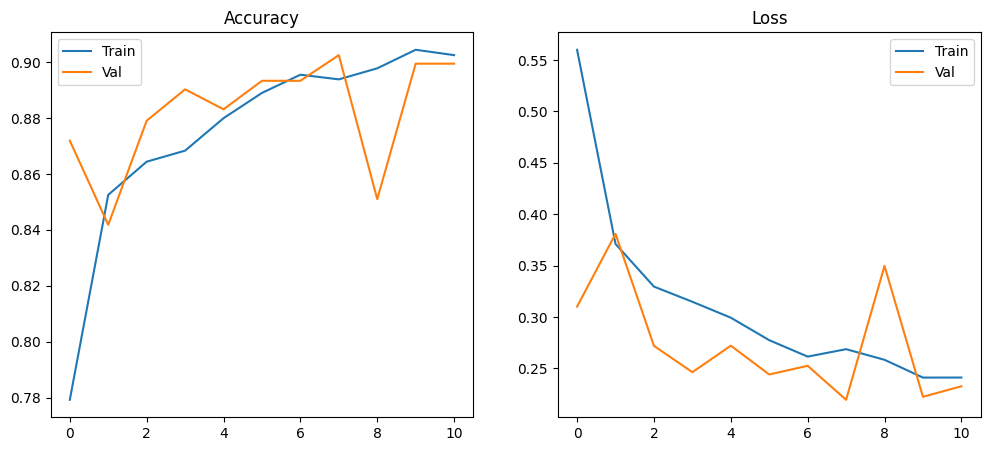

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.show()

62/62 ━━━━━━━━━━━━━━━━━━━━ 32s 317ms/step


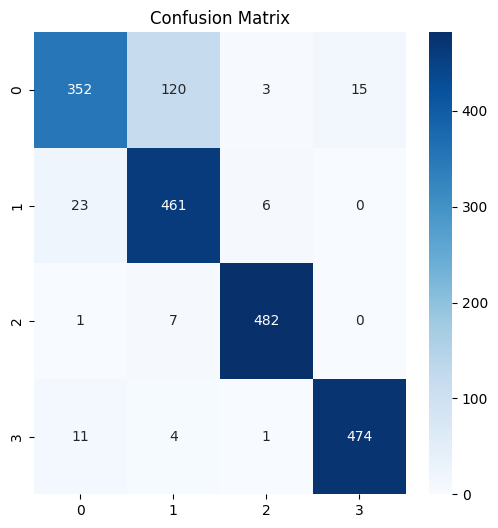

In [ ]:
y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(val_gen.classes, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(val_gen.classes, y_pred_classes, target_names=train_gen.class_indices.keys()))

              precision    recall  f1-score   support

       COVID       0.91      0.72      0.80       490
      NORMAL       0.78      0.94      0.85       490
   PNEUMONIA       0.98      0.98      0.98       490
          TB       0.97      0.97      0.97       490

    accuracy                           0.90      1960
   macro avg       0.91      0.90      0.90      1960
weighted avg       0.91      0.90      0.90      1960



In [30]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = val_gen.classes

# ✅ Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"✅ Accuracy: {accuracy:.4f}")

62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step
✅ Accuracy: 0.9026



🔍 Testing class: PNEUMONIA


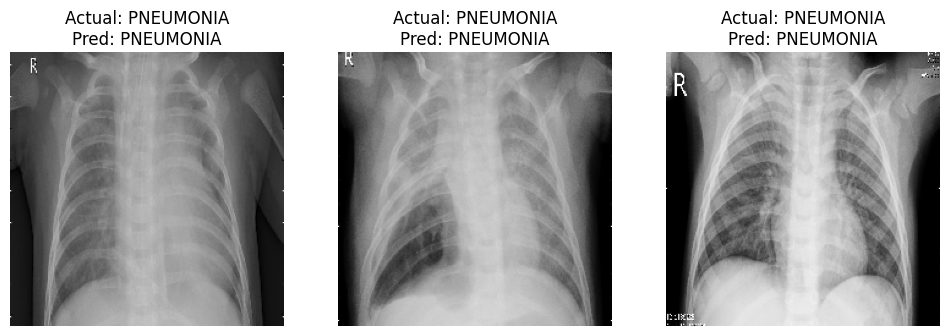


🔍 Testing class: TB


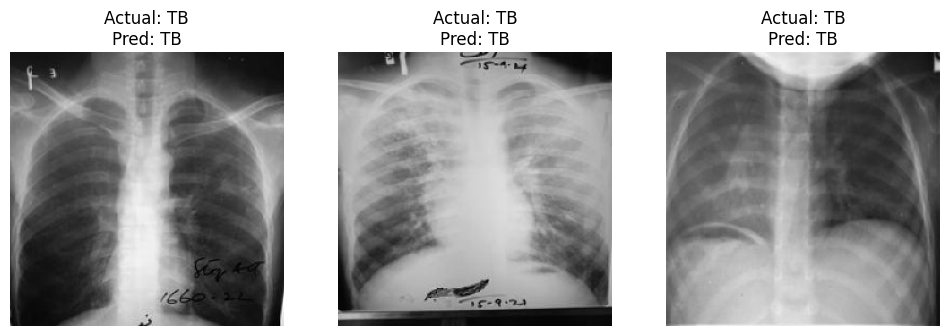


🔍 Testing class: COVID


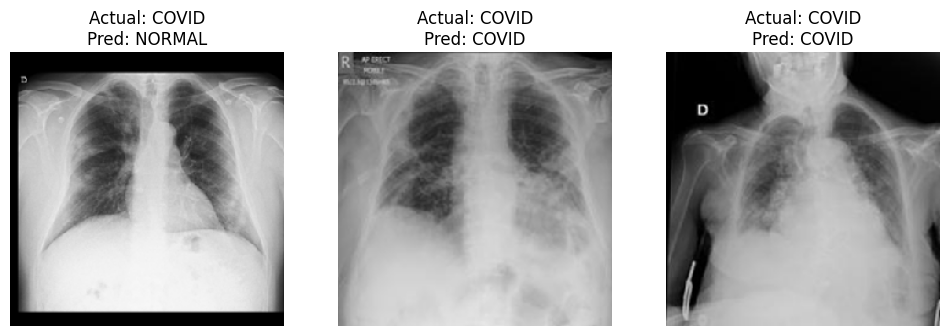


🔍 Testing class: NORMAL


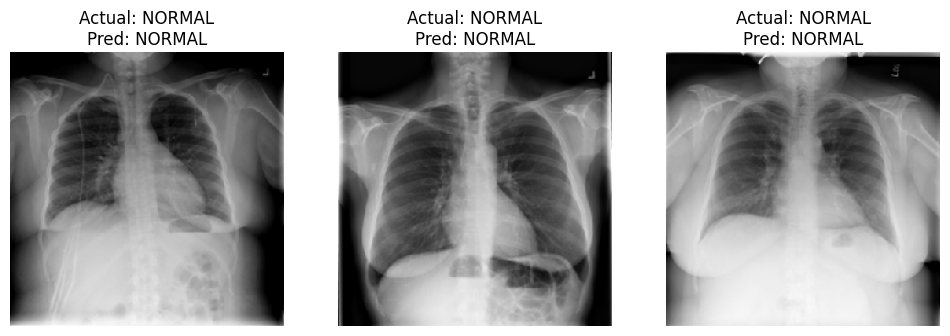

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
from tensorflow.keras.preprocessing import image

# Class names (IMPORTANT: same order as training)
class_names = list(train_gen.class_indices.keys())

# Dataset paths (original datasets)
test_paths = {
    "PNEUMONIA": "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA",
    "TB": "/kaggle/input/datasets/yasserhessein/tuberculosis-chest-x-rays-images/Dataset of Tuberculosis Chest X-rays Images/TB Chest X-rays",
    "COVID": "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images",
    "NORMAL": "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images"
}

IMG_SIZE = (224, 224)

# Function to predict single image
def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(pred)]

    return img, pred_class

# Loop through each class
for label, path in test_paths.items():
    print(f"\n🔍 Testing class: {label}")
    
    files = [f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    samples = random.sample(files, 3)  # pick 3 random images

    plt.figure(figsize=(12,4))

    for i, f in enumerate(samples):
        img_path = os.path.join(path, f)
        
        img, pred_class = predict_image(img_path)

        plt.subplot(1,3,i+1)
        plt.imshow(img)
        plt.title(f"Actual: {label}\nPred: {pred_class}")
        plt.axis('off')

    plt.show()


🔍 Testing class: PNEUMONIA


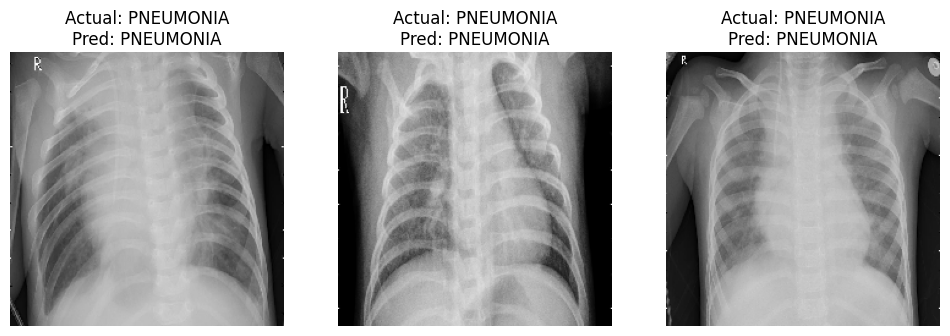


🔍 Testing class: TB


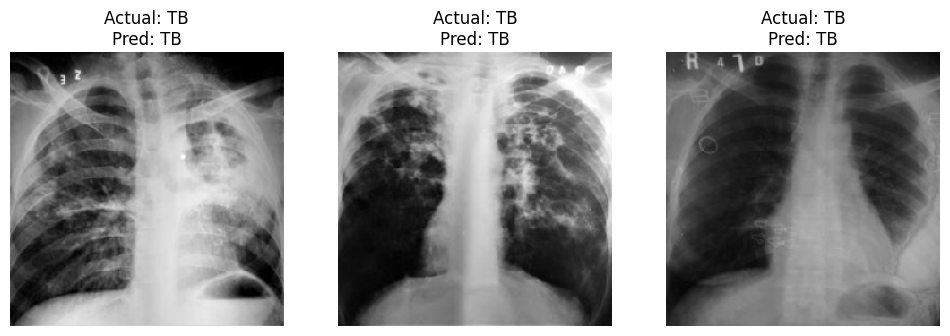


🔍 Testing class: COVID


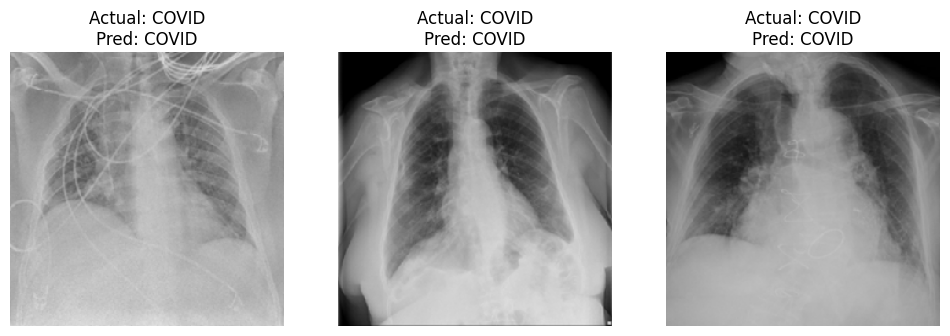


🔍 Testing class: NORMAL


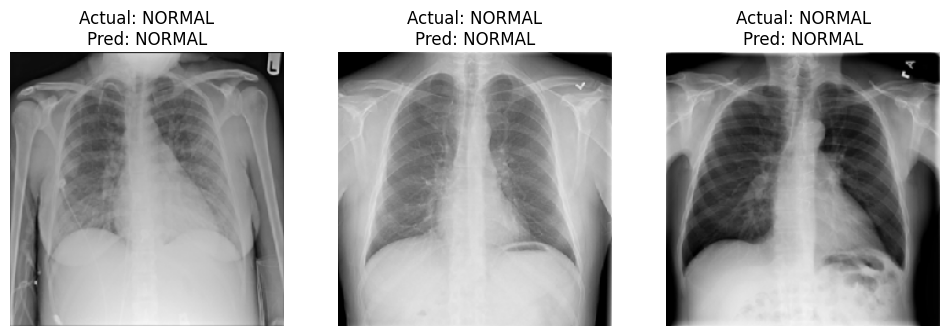

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import random
from tensorflow.keras.preprocessing import image

# Class names (IMPORTANT: same order as training)
class_names = list(train_gen.class_indices.keys())

# Dataset paths (original datasets)
test_paths = {
    "PNEUMONIA": "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA",
    "TB": "/kaggle/input/datasets/yasserhessein/tuberculosis-chest-x-rays-images/Dataset of Tuberculosis Chest X-rays Images/TB Chest X-rays",
    "COVID": "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images",
    "NORMAL": "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images"
}

IMG_SIZE = (224, 224)

# Function to predict single image
def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(pred)]

    return img, pred_class

# Loop through each class
for label, path in test_paths.items():
    print(f"\n🔍 Testing class: {label}")
    
    files = [f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    samples = random.sample(files, 3)  # pick 3 random images

    plt.figure(figsize=(12,4))

    for i, f in enumerate(samples):
        img_path = os.path.join(path, f)
        
        img, pred_class = predict_image(img_path)

        plt.subplot(1,3,i+1)
        plt.imshow(img)
        plt.title(f"Actual: {label}\nPred: {pred_class}")
        plt.axis('off')

    plt.show()

In [32]:
# Save model
model.save("/kaggle/working/lung_model.h5")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [33]:
from tensorflow.keras.models import load_model

# Load saved model
loaded_model = load_model("/kaggle/working/lung_model.h5")

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [34]:
import numpy as np
from tensorflow.keras.preprocessing import image

IMG_SIZE = (224, 224)

# Class names (IMPORTANT: same as training)
class_names = list(train_gen.class_indices.keys())

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = loaded_model.predict(img_array, verbose=0)
    
    pred_class = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    return img, pred_class, confidence


🔍 Testing class: PNEUMONIA


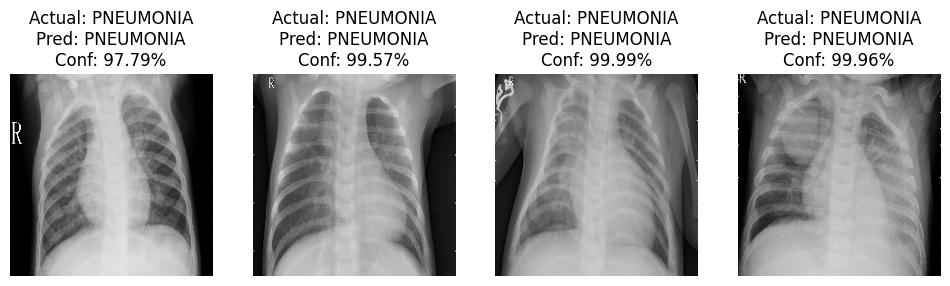


🔍 Testing class: TB


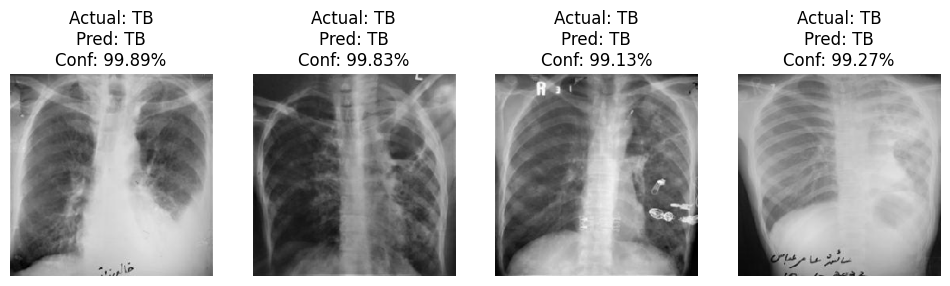


🔍 Testing class: COVID


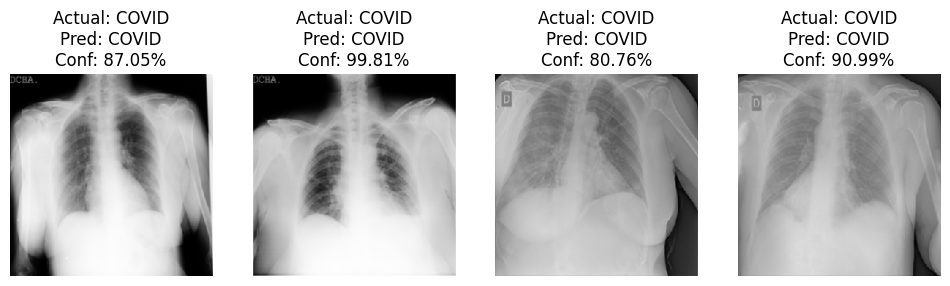


🔍 Testing class: NORMAL


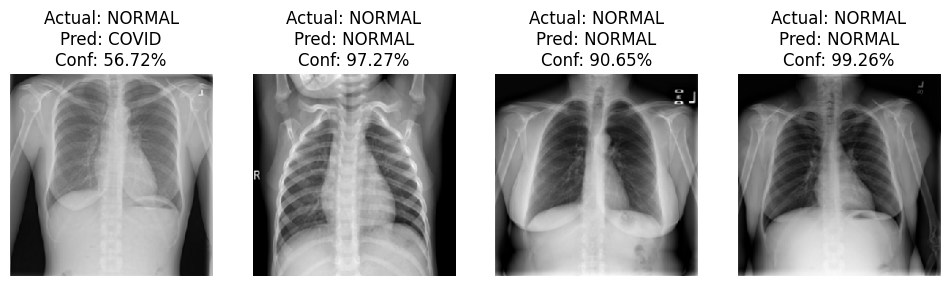

In [35]:
import matplotlib.pyplot as plt
import random
import os

# Dataset paths
test_paths = {
    "PNEUMONIA": "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA",
    "TB": "/kaggle/input/datasets/yasserhessein/tuberculosis-chest-x-rays-images/Dataset of Tuberculosis Chest X-rays Images/TB Chest X-rays",
    "COVID": "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images",
    "NORMAL": "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images"
}

# Loop through classes
for label, path in test_paths.items():
    print(f"\n🔍 Testing class: {label}")
    
    files = [f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    samples = random.sample(files, 4)  # pick 4 images

    plt.figure(figsize=(12,4))

    for i, f in enumerate(samples):
        img_path = os.path.join(path, f)
        
        img, pred_class, confidence = predict_image(img_path)

        plt.subplot(1,4,i+1)
        plt.imshow(img)
        plt.title(f"Actual: {label}\nPred: {pred_class}\nConf: {confidence:.2f}%")
        plt.axis('off')

    plt.show()